# Task 1

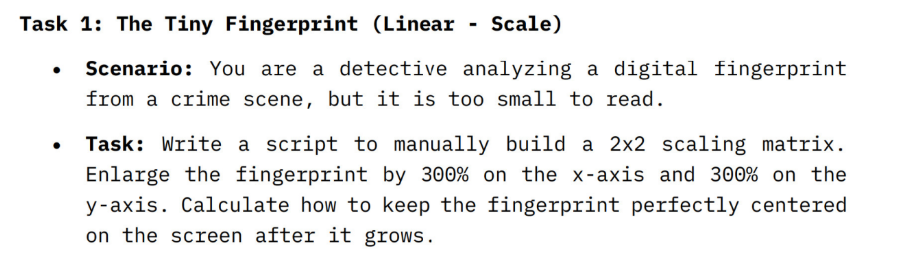

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

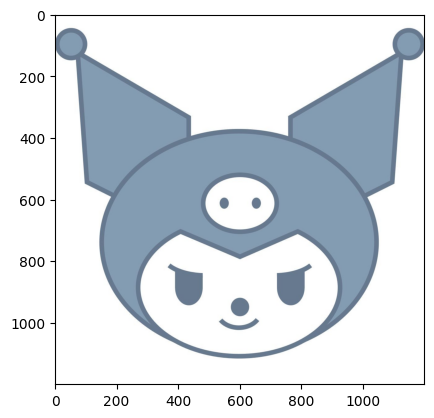

In [2]:
image_path = "test.jpg"
image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.show()

In [3]:
image.shape

(1200, 1200, 3)

In [4]:
sx, sy = 3.0, 3.0 #scaling x and y by 300%
s = np.array([[sx, 0], [0, sy]], dtype=np.float32)
h, w = image.shape[:2]
print("Size: ", h, w)
W, H = 600, 600
tx = W/2 - sx * w/2
ty = H/2 - sy * h/2
print("Shift: ", tx, ty)

Size:  1200 1200
Shift:  -1500.0 -1500.0


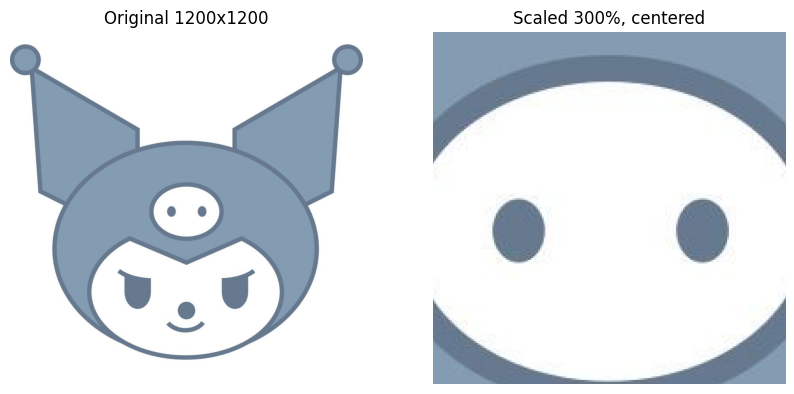

In [5]:
output = np.zeros((H, W, 3), dtype=np.uint8)

#Inverse mapping: for every output pixel, find its source pixel
S_inv = np.linalg.inv(s)
for y_out in range(H):
  for x_out in range(W):
    # undo the translation, then undo the scaling
    src = S_inv @ np.array([x_out - tx, y_out-ty])
    x_src, y_src = int(round(src[0])), int(round(src[1]))
    if 0 <= x_src < w and 0 <= y_src < h:
      output[y_out, x_out] = image_rgb[y_src, x_src]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_rgb);  ax[0].set_title(f'Original {w}x{h}')
ax[1].imshow(output);  ax[1].set_title('Scaled 300%, centered')
for a in ax: a.axis('off')
plt.show()

Shift: 180.0 180.0


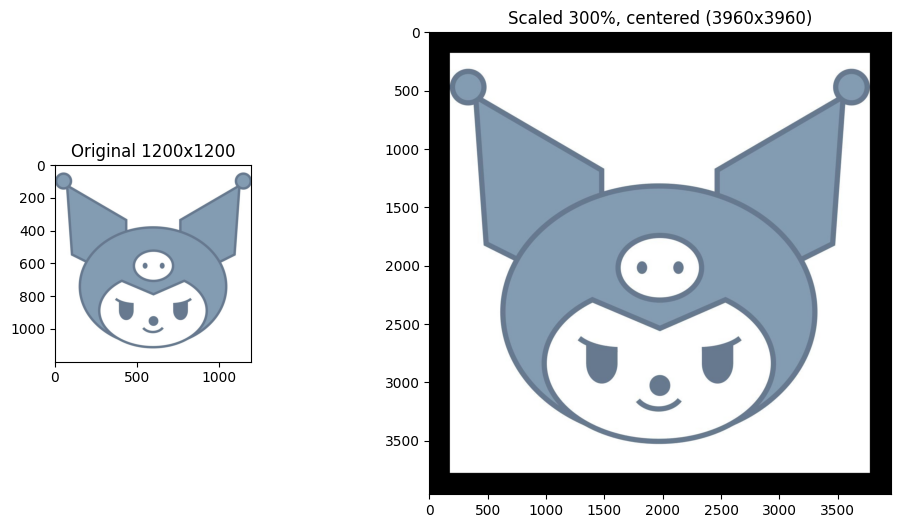

In [6]:
sx, sy = 3, 3
h, w = image_rgb.shape[:2]

# Canvas big enough to hold the 3x image, with a margin
W = H = int(max(sx * w, sy * h) * 1.1)

tx = W / 2 - sx * (w / 2)
ty = H / 2 - sy * (h / 2)
print("Shift:", tx, ty)

output = np.zeros((H, W, 3), dtype=np.uint8)
S_inv = np.linalg.inv(np.array([[sx, 0], [0, sy]], dtype=np.float32))

for y_out in range(H):
    for x_out in range(W):
        src = S_inv @ np.array([x_out - tx, y_out - ty])
        x_src, y_src = int(round(src[0])), int(round(src[1]))
        if 0 <= x_src < w and 0 <= y_src < h:
            output[y_out, x_out] = image_rgb[y_src, x_src]


fig, ax = plt.subplots(1, 2, figsize=(12, 6),gridspec_kw={'width_ratios': [w, W]})
ax[0].imshow(image_rgb); ax[0].set_title(f'Original {w}x{h}')
ax[1].imshow(output);    ax[1].set_title(f'Scaled 300%, centered ({W}x{H})')
plt.show()

# Task 2:
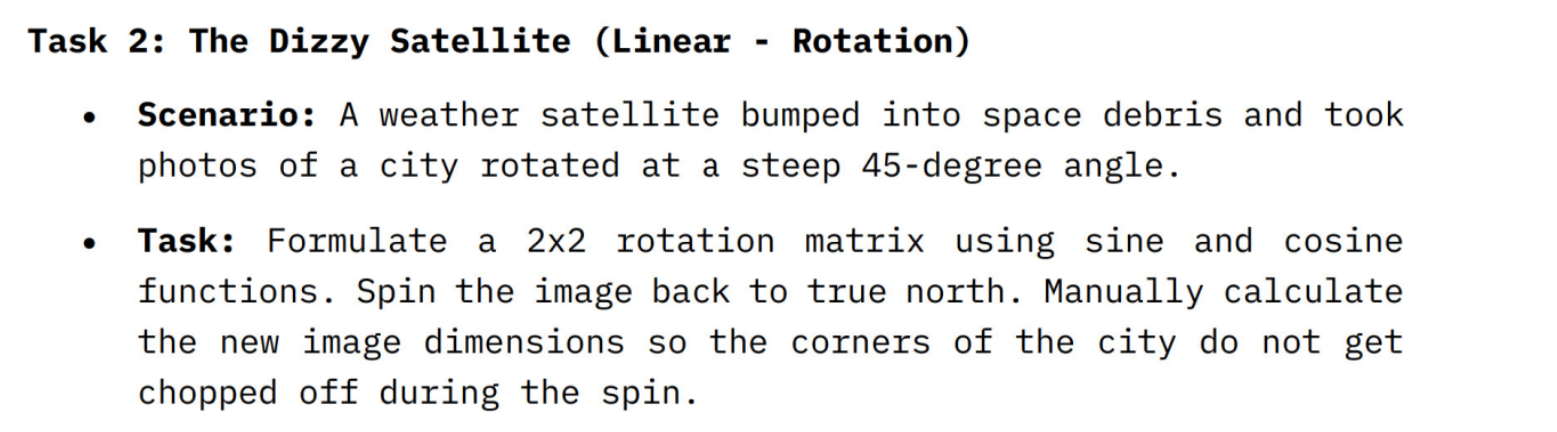

In [7]:
theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
R

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

In [19]:
def manual_rotation(image, theta):
  h, w = image.shape[:2]
  new_w = int(np.ceil(abs(w*np.cos(theta)) + abs(h*np.sin(theta))))
  new_h = int(np.ceil(abs(h*np.cos(theta)) + abs(w*np.sin(theta))))
  center = (w//2, h//2)

  alpha = np.cos(theta)
  beta = np.sin(theta)
  tx = (new_w - w) / 2
  ty = (new_h - h) / 2
  M = np.array([[alpha, -beta, center[0] - alpha*center[0] + beta*center[1] + tx],
                [beta, alpha, center[1] - beta*center[0] - alpha*center[1] + ty]])

  #M = cv2.getRotationMatrix2D(center, np.degrees(theta), 1.0)
  #M[0, 2] += (new_w - w) / 2
  #M[1, 2] += (new_h - h) / 2
  return cv2.warpAffine(image, M, (new_w, new_h))

Original shape:  (1200, 1200, 3)
Tilted shape:  (1698, 1698, 3)
Back to north shape:  (2402, 2402, 3)


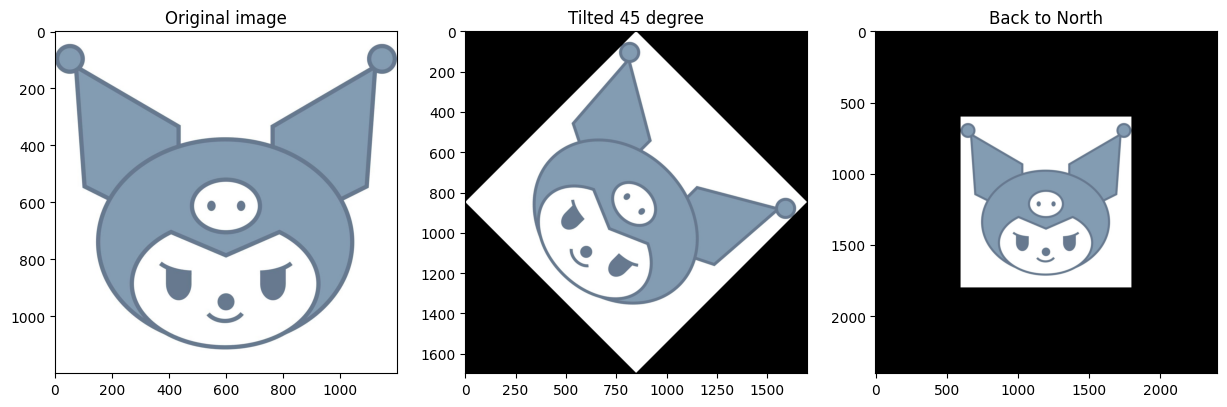

In [21]:
tilted_img = manual_rotation(image_rgb, np.deg2rad(45))
back_2_north= manual_rotation(tilted_img, np.deg2rad(-45))

print("Original shape: ", image_rgb.shape)
print("Tilted shape: ", tilted_img.shape)
print("Back to north shape: ", back_2_north.shape)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original image")
plt.subplot(1, 3, 2)
plt.imshow(tilted_img)
plt.title("Tilted 45 degree")
plt.subplot(1, 3, 3)
plt.imshow(back_2_north)
plt.title("Back to North")
plt.show()

# Task 3

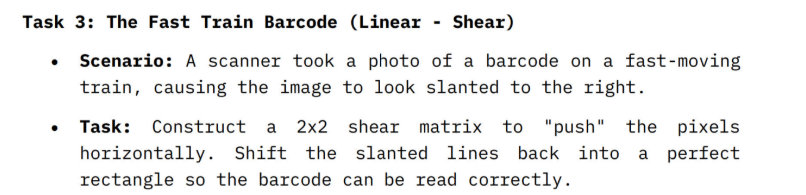

In [4]:
def shear_x(img, k, fill=255):
  h, w = img.shape[:2]

  #1. the 2x2 shear matrix
  shear = np.array([[1, k], [0, 1]], dtype=np.float64)

  #2. New width: shear the 4 corners, take the bounding box
  corners = np.array([[0, 0], [w-1, 0], [0, h-1], [w-1, h-1]])
  sheared = corners @ shear.T
  min_x, max_x = sheared[:, 0].min(), sheared[:, 0].max()
  new_w = int(np.ceil(max_x - min_x)) + 1
  tx = -min_x #shift so nothing is cut off

  # 3. Build the 2x3 matrix: [shear | translation]
  M = np.hstack([shear, [[tx], [0]]])

  # 4. Apply it
  out = cv2.warpAffine(img, M, (new_w, h), flags=cv2.INTER_NEAREST, borderValue=fill)
  print(f"k={k}: {w}x{h} -> {new_w}x{h}")
  return out

k=-0.4: 400x190 -> 476x190
k=0.4: 476x190 -> 552x190


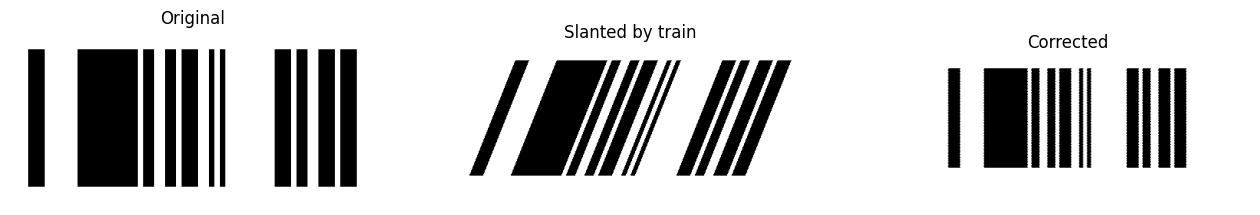

In [5]:
# ---- Make a fake barcode ----
rng = np.random.default_rng(0)
bars = rng.integers(0, 2, 60)
strip = np.repeat(np.where(bars == 1, 0, 255), 6).astype(np.uint8)
barcode = np.tile(strip, (150, 1))
barcode = np.pad(barcode, 20, constant_values=255)

# ---- Simulate the train: slants right (top is further right) ----
slanted = shear_x(barcode, -0.4)

# ---- Fix it: shear the opposite way ----
fixed = shear_x(slanted, +0.4)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, im, t in zip(ax, [barcode, slanted, fixed],
                    ['Original', 'Slanted by train', 'Corrected']):
    a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
plt.show()

# Task 4

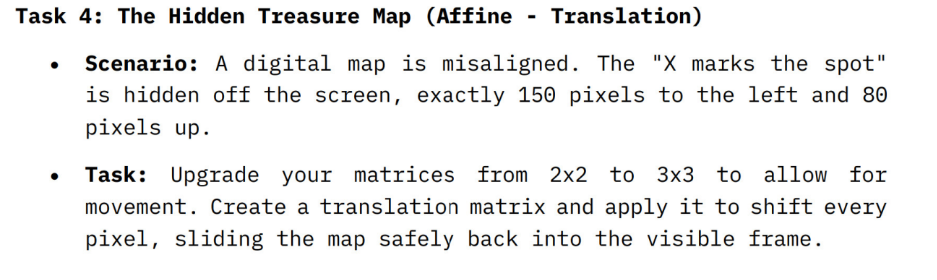

In [7]:
image = cv2.imread("test.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image.shape

(1200, 1200, 3)

In [9]:
h, w = image.shape[:2]
pad_top = 80
pad_left = 150
world = cv2.copyMakeBorder(image, pad_top, 0, pad_left, 0, cv2.BORDER_CONSTANT, value=(210, 190, 150))
mark = (60, 40)
#drawing x
cv2.line(world, (mark[0] - 20, mark[1] - 20), (mark[0]+20, mark[1]+20), (255, 0, 0), 6)
cv2.line(world, (mark[0] - 20, mark[1] + 20), (mark[0]+20, mark[1]-20), (255, 0, 0), 6)

D = np.array([[1, 0, -150], [0, 1, -80], [0, 0, 1]], dtype=np.float64)
T = np.array([[1, 0, 150], [0, 1, 80], [0, 0, 1]], dtype=np.float64)

before = cv2.warpAffine(world, D[:2], (w,h))
fixed = cv2.warpAffine(world, (T @ D)[:2], (w,h))

In [10]:
p = np.array([mark[0], mark[1], 1])
print('X before:', (D @ p)[:2])
print('X after:', (T @ D @ p)[:2])

X before: [-90. -40.]
X after: [60. 40.]


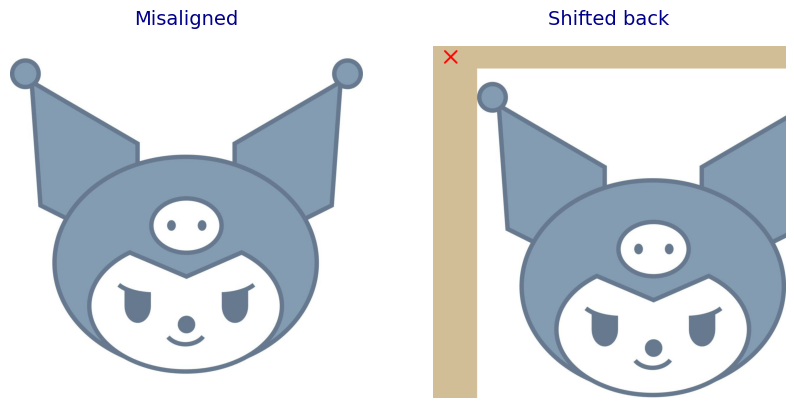

In [12]:
panels = [
    ('Misaligned', before),
    ('Shifted back', fixed)
]

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
for ax, (title, im) in zip(axes, panels):
  ax.imshow(im, cmap='gray')
  ax.axis('off')
  ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 5:
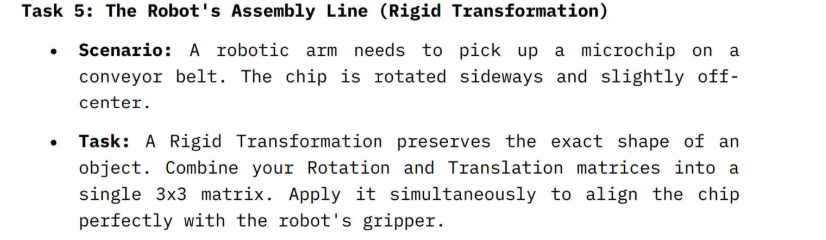

In [4]:
image = cv2.imread("test.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image.shape

(1200, 1200, 3)

In [5]:
def translation(tx, ty):
  return np.array([[1, 0, tx], [0, 1, ty], [0,0,1]], dtype=np.float64)

def rotation(angle, c):
  a = np.deg2rad(angle)
  R = np.array([[np.cos(a), np.sin(a), 0], [-np.sin(a), np.cos(a), 0], [0, 0, 1]])
  return translation(*c) @ R @ translation(-c[0], -c[1])

def scaling(s, c):
  S = np.array([[s, 0, 0], [0, s, 0], [0, 0, 1]], dtype=np.float64)
  return translation(*c) @ S @ translation(-c[0], -c[1])

In [10]:
h, w = image.shape[:2]
canvas = (2400, 2400)
offset = np.array([170, -130])
grip = np.array([1200, 1200])
angle = 25

place = translation(*(grip+offset-np.array([w/2, h/2])))
misaligned = cv2.warpAffine(image, (rotation(angle, grip+offset) @ place)[:2], canvas)

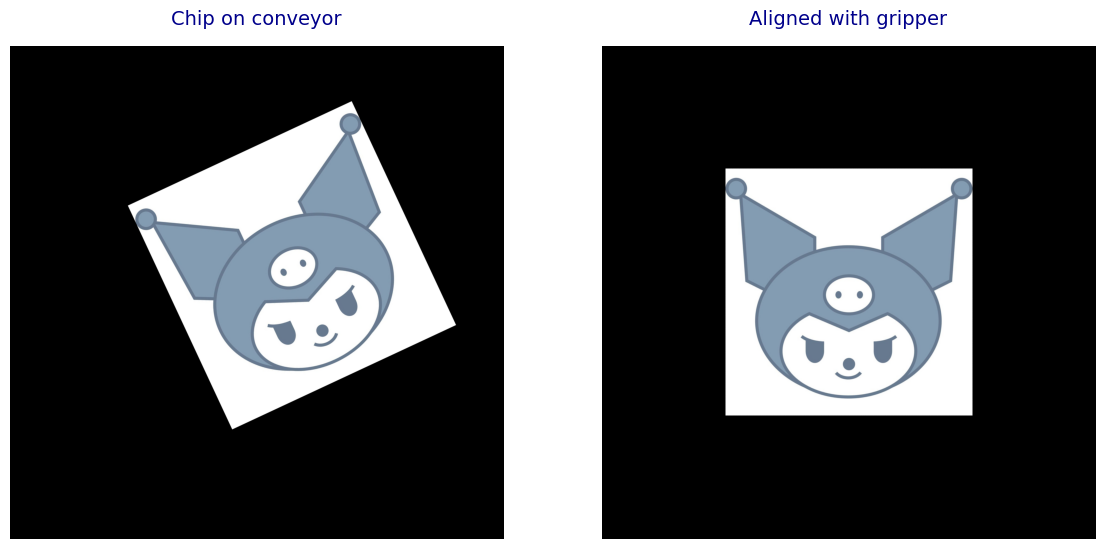

In [11]:
R = rotation(-angle, grip+offset)
T = translation(*(-offset))
M = T @ R
fixed = cv2.warpAffine(misaligned, M[:2], canvas)

panels = [('Chip on conveyor', misaligned), ('Aligned with gripper', fixed)]
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 6:
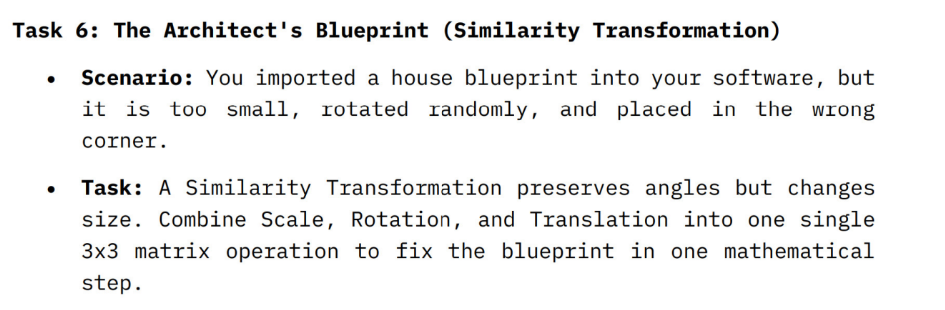

In [27]:
h, w = image.shape[:2]
c = np.array([w/2, h/2])
canvas = (1800, 1800)
corner = np.array([1450, 1450])
s, angle = 0.4, 35

D = rotation(angle, corner) @ translation(*(corner-c)) @ scaling(s,c)
blueprint = cv2.warpAffine(image, D[:2], canvas)

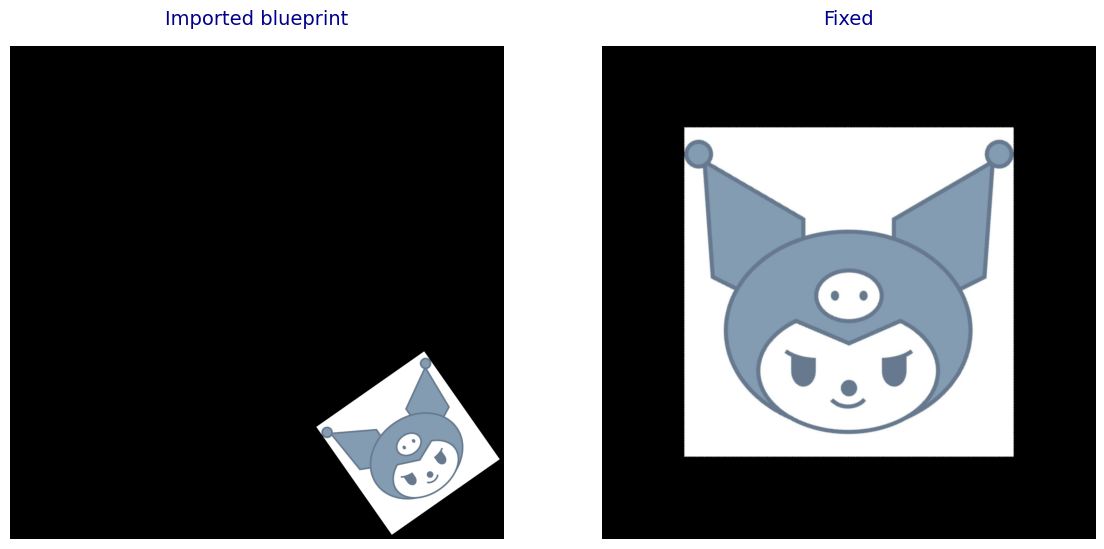

In [34]:
center = np.array([canvas[0]/ 2, canvas[1]/2])
R = rotation(-angle, corner)
S = scaling(1/s, corner)
T = translation(*(center-corner))
M = T @ S @ R
fixed = cv2.warpAffine(blueprint, M[:2], canvas)

panels = [('Imported blueprint', blueprint), ('Fixed', fixed)]
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.flatten()
for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 7:
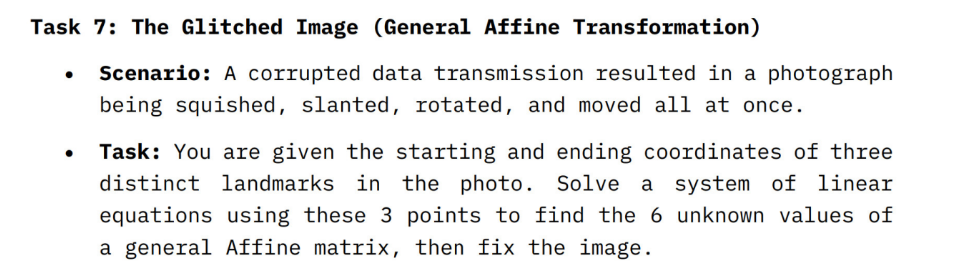

In [2]:
image = cv2.imread("test.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image.shape

(1200, 1200, 3)

In [18]:
h, w = image.shape[:2]
A_true = np.array([[0.8, 0.3, 20], [0.15, 0.7, 10]], dtype=np.float64)
landmarks = np.array([[60, 50], [200, 60], [120, 150]], dtype=np.float64)
glitched_pts = np.round(landmarks @ A_true[:, :2].T + A_true[:, 2]) #A_true[:, :2] -> gives all rows but only the first 2 columns i.e column 0 and column1 cuz column2 is the translation vector which we add later
glitched_pts

array([[ 83.,  54.],
       [198.,  82.],
       [161., 133.]])

In [25]:
glitched = cv2.warpAffine(image, A_true, (1400, 1400))
P = np.hstack([glitched_pts, np.ones((3, 1))])

abc = np.linalg.solve(P, landmarks[:, 0])
_def = np.linalg.solve(P, landmarks[:, 1])

M = np.array([abc, _def])
fixed = cv2.warpAffine(glitched, M, (w,h))
print(np.round(M, 3))
print('cv2.getAffineTransform:')
print(np.round(cv2.getAffineTransform(np.float32(glitched_pts), np.float32(landmarks)), 3))

[[  1.359  -0.583 -21.359]
 [ -0.291   1.553  -9.709]]
cv2.getAffineTransform:
[[  1.359  -0.583 -21.359]
 [ -0.291   1.553  -9.709]]


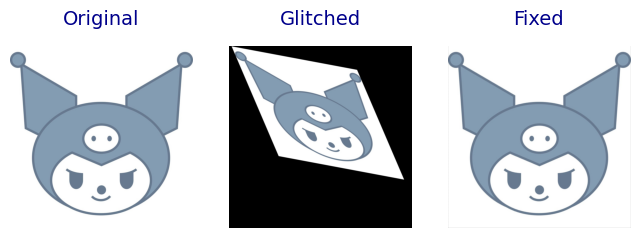

In [26]:
panels = [('Original', image), ('Glitched', glitched), ('Fixed', fixed)]

fig, axes = plt.subplots(1, 3, figsize=(8, 6))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

# Task 8:
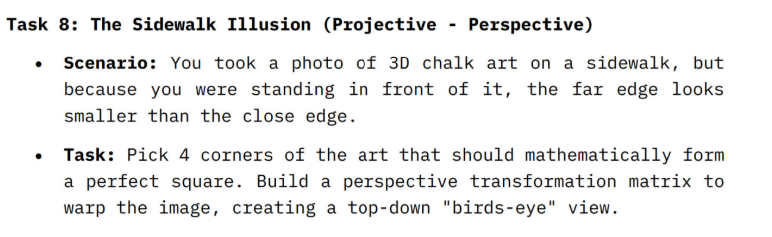

In [27]:
image = cv2.imread("sudoku.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image.shape

(563, 558, 3)

In [28]:
def homography(src, destination):
  A, b = [], []
  for(x,y), (u,v) in zip(src, destination):
    A.append([x, y, 1, 0, 0, 0, -u*x, -u*y])
    b.append(u)
    A.append([0, 0, 0, x, y, 1, -v*x, -v*y])
    b.append(v)
  h = np.linalg.solve(np.array(A, dtype=np.float64), np.array(b, dtype=np.float64))
  return np.append(h, 1).reshape(3,3)

In [30]:
h, w = image.shape[:2]
art = np.float64([[0, 0], [w, 0], [w, h], [0, h]])
quad = np.float64([[220, 120], [580, 120], [760, 640], [40, 640]])
photo = cv2.warpPerspective(image, homography(art, quad), (800, 700), borderValue=(120, 120, 120))
photo.shape

(700, 800, 3)

In [32]:
size = 500
square = np.float64([[0, 0], [size, 0], [size, size], [0, size]])

H = homography(quad, square)
fixed = cv2.warpPerspective(photo, H, (size, size))

print(np.round(H, 4))
print('matches cv2:', np.allclose(H, cv2.getPerspectiveTransform(np.float32(quad), np.float32(square)), atol=1e-3))

[[ 1.805600e+00  6.250000e-01 -4.722222e+02]
 [ 0.000000e+00  2.500000e+00 -3.000000e+02]
 [ 0.000000e+00  2.500000e-03  1.000000e+00]]
matches cv2: True


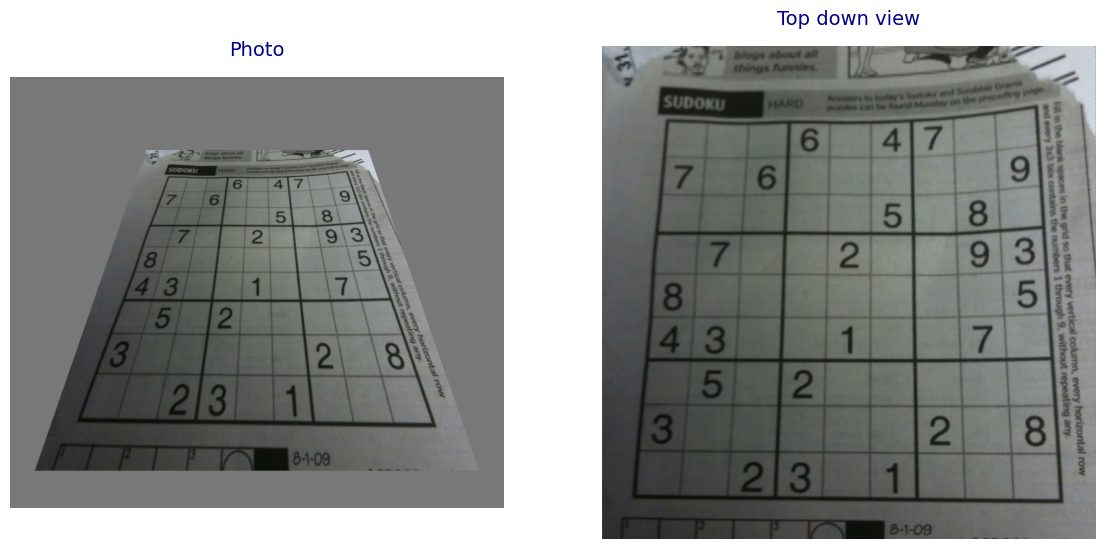

In [33]:
panels = [('Photo', photo), ('Top down view', fixed)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()